# ODL-VC with 24-hour Profiles (Compressed) — Import/Export


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from hybrid_acdc_odlvc.config import PlantParams, ControlParams, ProfileParams
from hybrid_acdc_odlvc.profiles import default_profiles_24h
from hybrid_acdc_odlvc.sim import run_sim_24h


In [2]:
pp = PlantParams(Ts=1e-4)
cp = ControlParams()
pr = ProfileParams(compress_24h_to_s=24.0, P_ren_max_w=18000.0)
prof = default_profiles_24h()

baseline = run_sim_24h(pp, cp, pr, prof, 'baseline_pi', pr.compress_24h_to_s)
odl = run_sim_24h(pp, cp, pr, prof, 'odl_vc', pr.compress_24h_to_s)
t = odl['t']


In [3]:
# ---- Plot decimation (avoid dense filled plots at 10 kHz) ----
dec = 50  # plot every 50th sample (10 kHz -> 200 Hz visual)
td = t[::dec]
baseline_d = {k: baseline[k][::dec] for k in baseline}
odl_d = {k: odl[k][::dec] for k in odl}


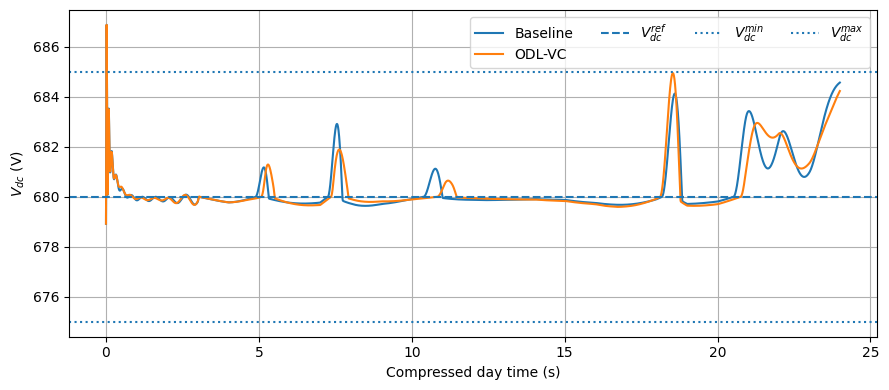

In [4]:
# Vdc with constraint band
plt.figure(figsize=(9,4))
plt.plot(td, baseline_d['Vdc'], label='Baseline')
plt.plot(td, odl_d['Vdc'], label='ODL-VC')
plt.axhline(cp.Vdc_ref, linestyle='--', label='$V_{dc}^{ref}$')
plt.axhline(cp.Vdc_min, linestyle=':', label='$V_{dc}^{min}$')
plt.axhline(cp.Vdc_max, linestyle=':', label='$V_{dc}^{max}$')
plt.xlabel('Compressed day time (s)'); plt.ylabel('$V_{dc}$ (V)')
plt.grid(True); plt.legend(ncol=4); plt.tight_layout(); plt.show()


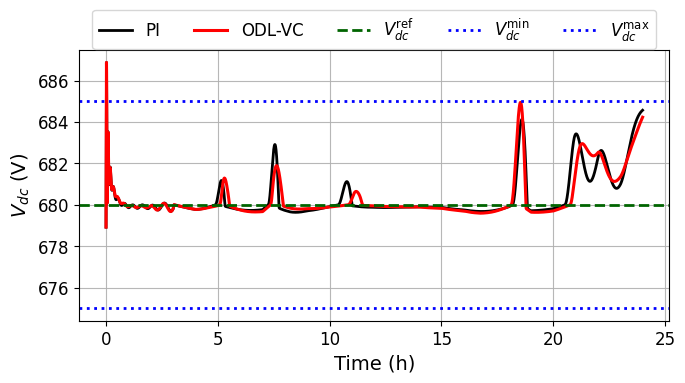

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

# ---- Vdc trajectories ----
plt.plot(
    td,
    baseline_d['Vdc'],
    color='black',
    linewidth=2,
    label='PI'
)

plt.plot(
    td,
    odl_d['Vdc'],
    color='red',
    linewidth=2.2,
    label='ODL-VC'
)

# ---- Reference and constraint limits ----
plt.axhline(
    cp.Vdc_ref,
    linestyle='--',
    color='DarkGreen',
    linewidth=2,
    label=r'$V_{dc}^{\mathrm{ref}}$'
)

plt.axhline(
    cp.Vdc_min,
    linestyle=':',
    color='blue',
    linewidth=2,
    label=r'$V_{dc}^{\min}$'
)

plt.axhline(
    cp.Vdc_max,
    linestyle=':',
    color='blue',
    linewidth=2,
    label=r'$V_{dc}^{\max}$'
)

# ---- Formatting ----
plt.xlabel('Time (h)', fontsize=14)
plt.ylabel(r'$V_{dc}$ (V)', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, which='both', linestyle='-', linewidth=0.8, alpha=0.9)

# ---- Horizontal legend ----
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.18),
    ncol=5,
    fontsize=12,
    frameon=True
)

plt.tight_layout()

# ---- Save as vector PDF ----
plt.savefig(
    "Fig_Vdc_Constraint_Band_Comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


In [5]:
def lpf(x, alpha=0.02):
    y = np.zeros_like(x)
    y[0] = x[0]
    for k in range(1,len(x)):
        y[k] = (1-alpha)*y[k-1] + alpha*x[k]
    return y

id_f = lpf(odl_d['id'], alpha=0.02)


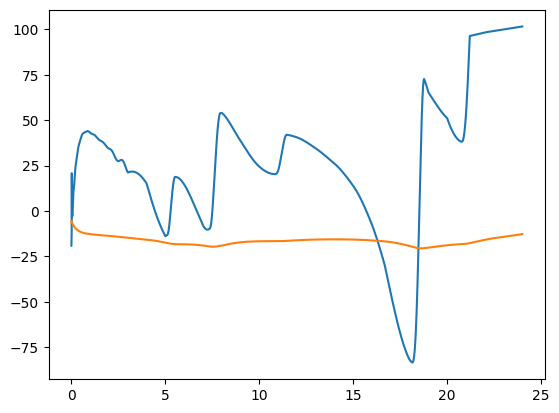

In [6]:
plt.plot(td, odl_d['id_ref'], label='$i_d^*$')
plt.plot(td, id_f, label='$i_d$ (filtered)')


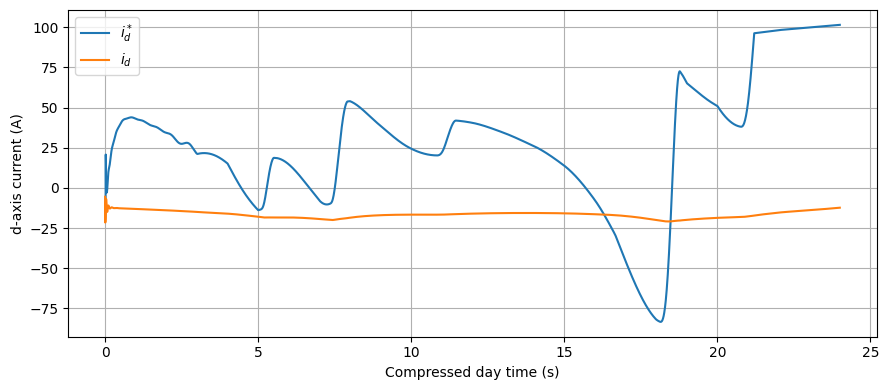

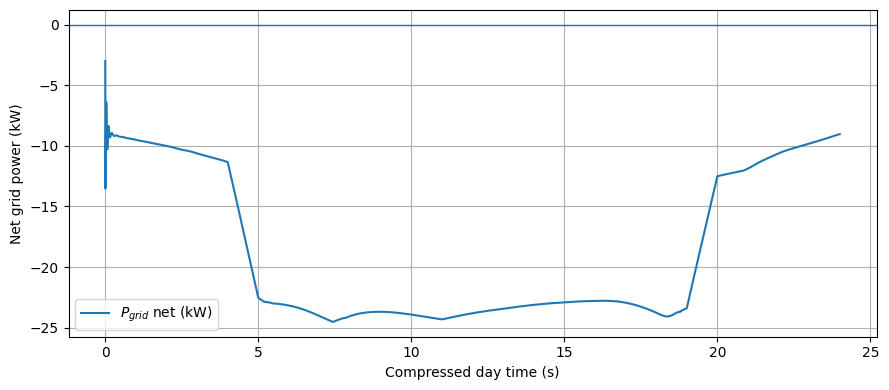

In [7]:
# id tracking and net grid power (import/export)
plt.figure(figsize=(9,4))
plt.plot(td, odl_d['id_ref'], label='$i_d^*$')
plt.plot(td, odl_d['id'], label='$i_d$')
plt.xlabel('Compressed day time (s)'); plt.ylabel('d-axis current (A)')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4))
plt.plot(td, odl_d['P_grid_net']/1000, label='$P_{grid}$ net (kW)')
plt.axhline(0, linewidth=1)
plt.xlabel('Compressed day time (s)'); plt.ylabel('Net grid power (kW)')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


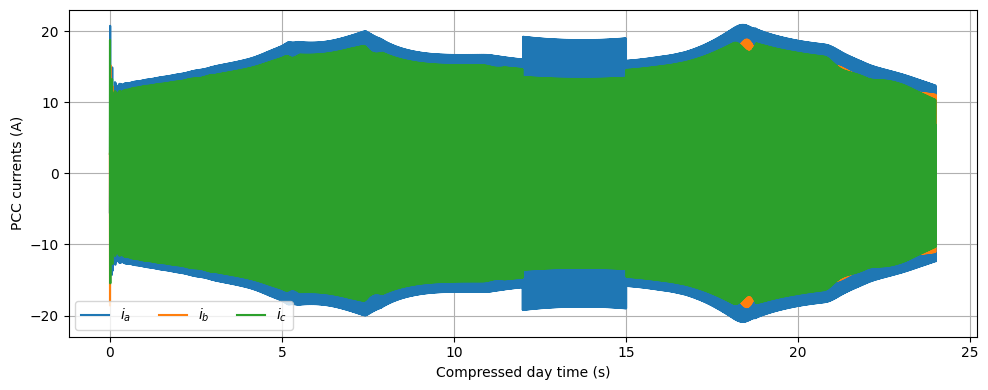

In [8]:
# PCC abc currents
plt.figure(figsize=(10,4))
plt.plot(td, odl_d['i_a'], label='$i_a$')
plt.plot(td, odl_d['i_b'], label='$i_b$')
plt.plot(td, odl_d['i_c'], label='$i_c$')
plt.xlabel('Compressed day time (s)'); plt.ylabel('PCC currents (A)')
plt.grid(True); plt.legend(ncol=3); plt.tight_layout(); plt.show()


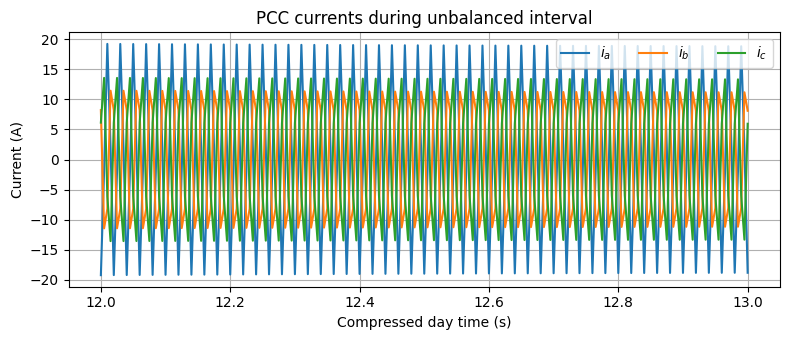

In [9]:
t1, t2 = 12.0, 13.0   # compressed hours
idx = (td >= t1) & (td <= t2)

plt.figure(figsize=(8,3.5))
plt.plot(td[idx], odl_d['i_a'][idx], label='$i_a$')
plt.plot(td[idx], odl_d['i_b'][idx], label='$i_b$')
plt.plot(td[idx], odl_d['i_c'][idx], label='$i_c$')
plt.xlabel('Compressed day time (s)')
plt.ylabel('Current (A)')
plt.title('PCC currents during unbalanced interval')
plt.grid(True); plt.legend(ncol=3)
plt.tight_layout(); plt.show()


C:\Users\asus\AppData\Local\Temp\ipykernel_5220\2255127935.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


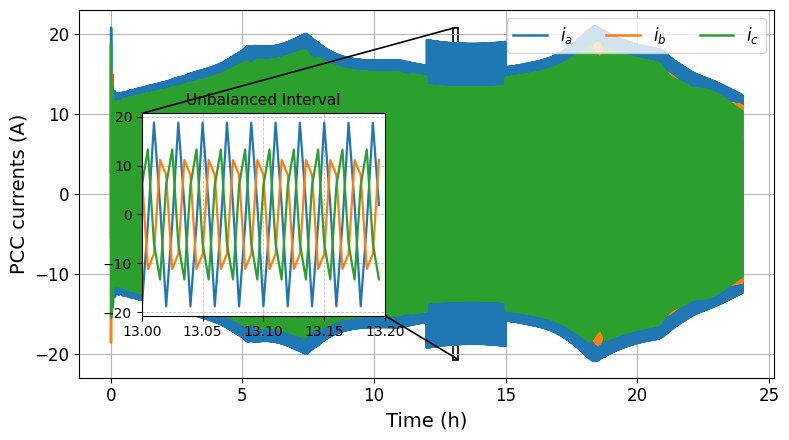

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ---- Main figure ----
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(td, odl_d['i_a'], linewidth=1.8, label=r'$i_a$')
ax.plot(td, odl_d['i_b'], linewidth=1.8, label=r'$i_b$')
ax.plot(td, odl_d['i_c'], linewidth=1.8, label=r'$i_c$')

ax.set_xlabel('Time (h)', fontsize=14)
ax.set_ylabel('PCC currents (A)', fontsize=14)

ax.tick_params(axis='both', labelsize=12)

ax.grid(True, linestyle='-', linewidth=0.8, alpha=0.9)
ax.legend(ncol=3, fontsize=12, loc='upper right')

# ---- Zoom-in interval ----
t1, t2 = 13.0, 13.2
idx = (td >= t1) & (td <= t2)

# ---- Inset axes ----
axins = inset_axes(
    ax,
    width="35%",     # size of inset
    height="55%",
    loc='lower left',
    bbox_to_anchor=(0.08, 0.15, 1, 1),
    bbox_transform=ax.transAxes
)

axins.plot(td[idx], odl_d['i_a'][idx], linewidth=1.6)
axins.plot(td[idx], odl_d['i_b'][idx], linewidth=1.6)
axins.plot(td[idx], odl_d['i_c'][idx], linewidth=1.6)

axins.set_xlim(t1, t2)
axins.tick_params(axis='both', labelsize=10)
axins.set_title('Unbalanced Interval', fontsize=11)

axins.grid(True, linestyle='--', linewidth=0.6, alpha=0.8)

# ---- Draw connecting box ----
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="black", linewidth=1.2)

plt.tight_layout()

# ---- Save as vector PDF (same directory) ----
plt.savefig(
    "Fig_PCC_Currents_with_Zoom.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


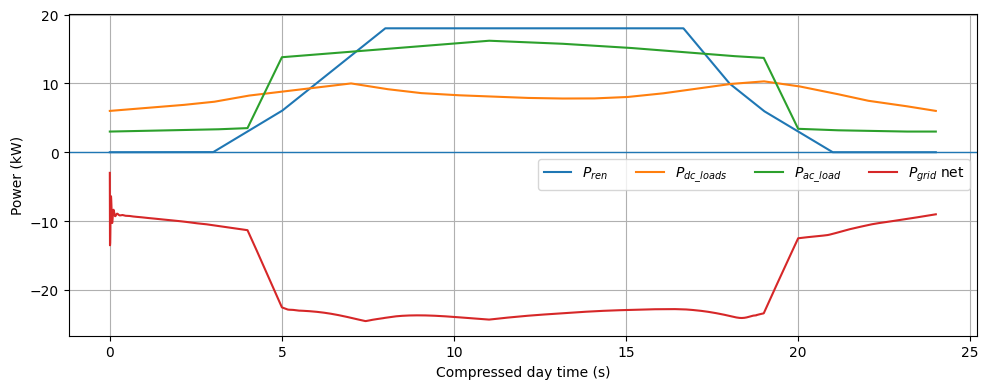

In [10]:
# Power overview
plt.figure(figsize=(10,4))
plt.plot(td, odl_d['P_ren']/1000, label='$P_{ren}$')
plt.plot(td, (odl_d['Pdc1']+odl_d['Pdc2'])/1000, label='$P_{dc\_loads}$')
plt.plot(td, odl_d['Pac_load']/1000, label='$P_{ac\_load}$')
plt.plot(td, odl_d['P_grid_net']/1000, label='$P_{grid}$ net')
plt.axhline(0, linewidth=1)
plt.xlabel('Compressed day time (s)'); plt.ylabel('Power (kW)')
plt.grid(True); plt.legend(ncol=4); plt.tight_layout(); plt.show()


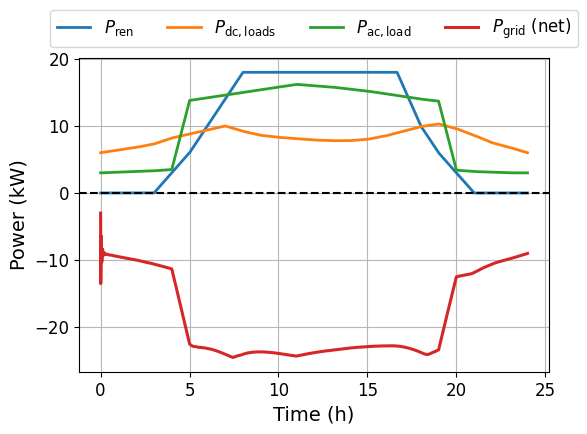

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4.5))

# ---- Power profiles ----
plt.plot(
    td,
    odl_d['P_ren']/1000,
    linewidth=2,
    label=r'$P_{\mathrm{ren}}$'
)

plt.plot(
    td,
    (odl_d['Pdc1'] + odl_d['Pdc2'])/1000,
    linewidth=2,
    label=r'$P_{\mathrm{dc,loads}}$'
)

plt.plot(
    td,
    odl_d['Pac_load']/1000,
    linewidth=2,
    label=r'$P_{\mathrm{ac,load}}$'
)

plt.plot(
    td,
    odl_d['P_grid_net']/1000,
    linewidth=2.2,
    label=r'$P_{\mathrm{grid}}$ (net)'
)

# ---- Zero reference ----
plt.axhline(0, linestyle='--', color='black', linewidth=1.5)

# ---- Formatting ----
plt.xlabel('Time (h)', fontsize=14)
plt.ylabel('Power (kW)', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, which='both', linestyle='-', linewidth=0.8, alpha=0.9)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.18),
    ncol=4,
    fontsize=12,
    frameon=True
)

plt.tight_layout()

# ---- Save as vector PDF (same directory) ----
plt.savefig(
    "Fig_Power_Overview.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


THD (phase-a) Baseline: 70.88%
THD (phase-a) ODL-VC : 70.85%


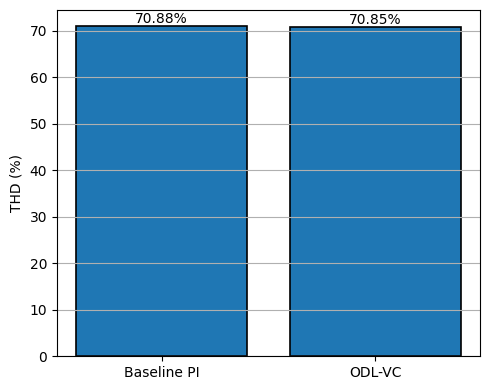

In [27]:
# 6) THD estimate for phase-a current (steady window)
def thd_fft(i, fs, f1=50.0):
    i = np.asarray(i)
    i = i - np.mean(i)
    n = len(i)
    w = np.hanning(n)
    I = np.fft.rfft(i*w)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(I)
    k1 = int(np.argmin(np.abs(freqs - f1)))
    fund = mag[k1]
    mag2 = mag.copy(); mag2[0]=0.0; mag2[k1]=0.0
    thd = np.sqrt(np.sum(mag2**2)) / (fund + 1e-12)
    return 100*thd

fs = 1/pp.Ts
t1, t2 = 0.40, 0.54
idx = np.where((t >= t1) & (t <= t2))[0]

thd_base = thd_fft(baseline['i_a'][idx], fs)
thd_odl  = thd_fft(odl['i_a'][idx], fs)
print(f"THD (phase-a) Baseline: {thd_base:.2f}%")
print(f"THD (phase-a) ODL-VC : {thd_odl:.2f}%")

plt.figure(figsize=(5,4))
bars = plt.bar(['Baseline PI','ODL-VC'], [thd_base, thd_odl], edgecolor='black', linewidth=1.2)
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.2f}%", ha='center', va='bottom')
plt.ylabel('THD (%)')
plt.grid(True, axis='y')
plt.tight_layout(); plt.show()


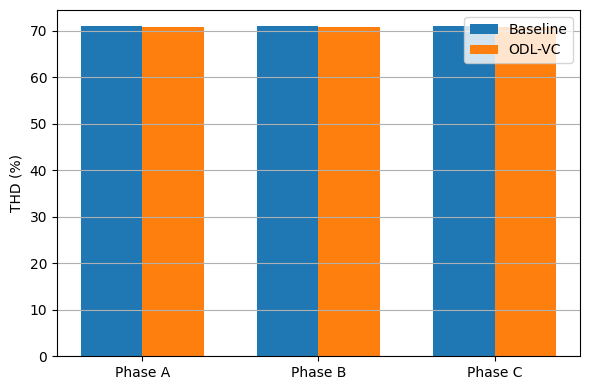

In [28]:
thd_base_a = thd_fft(baseline['i_a'][idx], fs)
thd_base_b = thd_fft(baseline['i_b'][idx], fs)
thd_base_c = thd_fft(baseline['i_c'][idx], fs)

thd_odl_a  = thd_fft(odl['i_a'][idx], fs)
thd_odl_b  = thd_fft(odl['i_b'][idx], fs)
thd_odl_c  = thd_fft(odl['i_c'][idx], fs)

labels = ['Phase A','Phase B','Phase C']
base_vals = [thd_base_a, thd_base_b, thd_base_c]
odl_vals  = [thd_odl_a,  thd_odl_b,  thd_odl_c]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(6,4))
plt.bar(x-w/2, base_vals, w, label='Baseline')
plt.bar(x+w/2, odl_vals,  w, label='ODL-VC')
plt.xticks(x, labels)
plt.ylabel('THD (%)')
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout(); plt.show()


In [29]:
import pandas as pd
import numpy as np

labels = ['Phase A', 'Phase B', 'Phase C']

table_thd = pd.DataFrame({
    'Phase': labels,
    'Baseline THD (%)': [thd_base_a, thd_base_b, thd_base_c],
    'ODL-VC THD (%)':   [thd_odl_a,  thd_odl_b,  thd_odl_c],
    'Reduction (%)': [
        (thd_base_a - thd_odl_a) / thd_base_a * 100,
        (thd_base_b - thd_odl_b) / thd_base_b * 100,
        (thd_base_c - thd_odl_c) / thd_base_c * 100
    ]
})

table_thd


,Phase,Baseline THD (%),ODL-VC THD (%),Reduction (%)
0,Phase A,70.882587,70.849418,0.046794
1,Phase B,70.883367,70.850140,0.046876
2,Phase C,70.883172,70.850063,0.046709
